In [2]:
import json
import pandas as pd
import numpy as np
import xarray as xr

import warnings
warnings.filterwarnings(
    "ignore",
    message="Degrees of freedom <= 0 for slice",
    category=RuntimeWarning
)

warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in log10",
    category=RuntimeWarning
)


json_file = (
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/loss_per_trial.json"
)

with open(json_file) as f:
    data = json.load(f)

rows = []

for trial_id, trial_data in data.items():
    params = trial_data["params"]

    # ----------------------------
    # GPP – water limited
    # ----------------------------
    for pft, loss in trial_data["gpp_loss_water"].items():
        slope_data = trial_data["gpp_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "GPP_water",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

    # ----------------------------
    # Mortality
    # ----------------------------
    for pft, loss in trial_data["mort_loss_per_pft"].items():
        slope_data = trial_data["mort_slopes"].get(pft, {})
        
        rows.append({
            "trial": int(trial_id),
            "process": "MORT",
            "pft": pft,
            "loss": np.nan if loss == 1e6 else loss,
            "slope": slope_data.get("slope", np.nan),
            "intercept": slope_data.get("intercept", np.nan),
            **params
        })

df = pd.DataFrame(rows)

# Optional: also clean slopes/intercepts if needed
df["slope"] = df["slope"].replace([1e6], np.nan)
df["intercept"] = df["intercept"].replace([1e6], np.nan)

df

,trial,process,pft,loss,slope,intercept,alpha_tropical_broadleaved_evergreen_tree,beta_tropical_broadleaved_evergreen_tree,alpha_tropical_broadleaved_raingreen_tree,beta_tropical_broadleaved_raingreen_tree,...,alpha_temperate_broadleaved_evergreen_tree,beta_temperate_broadleaved_evergreen_tree,alpha_temperate_broadleaved_summergreen_tree,beta_temperate_broadleaved_summergreen_tree,alpha_boreal_needleleaved_evergreen_tree,beta_boreal_needleleaved_evergreen_tree,alpha_boreal_broadleaved_summergreen_tree,beta_boreal_broadleaved_summergreen_tree,alpha_boreal_needleleaved_summergreen_tree,beta_boreal_needleleaved_summergreen_tree
0,0,GPP_water,tropical broadleaved evergreen tree,0.108019,0.032291,0.005857,0.090418,24.543210,0.202104,21.606160,...,0.048886,20.294376,0.569383,10.765296,0.432482,21.670161,0.202183,23.442855,0.752682,23.392404
1,0,GPP_water,tropical broadleaved raingreen tree,0.367635,-0.246255,-0.045652,0.090418,24.543210,0.202104,21.606160,...,0.048886,20.294376,0.569383,10.765296,0.432482,21.670161,0.202183,23.442855,0.752682,23.392404
2,0,GPP_water,temperate needleleaved evergreen tree,0.107658,0.224883,0.069919,0.090418,24.543210,0.202104,21.606160,...,0.048886,20.294376,0.569383,10.765296,0.432482,21.670161,0.202183,23.442855,0.752682,23.392404
3,0,GPP_water,temperate broadleaved evergreen tree,0.208691,-0.034553,-0.011256,0.090418,24.543210,0.202104,21.606160,...,0.048886,20.294376,0.569383,10.765296,0.432482,21.670161,0.202183,23.442855,0.752682,23.392404
4,0,GPP_water,temperate broadleaved summergreen tree,0.260871,-0.077639,-0.018687,0.090418,24.543210,0.202104,21.606160,...,0.048886,20.294376,0.569383,10.765296,0.432482,21.670161,0.202183,23.442855,0.752682,23.392404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,99,MORT,temperate broadleaved evergreen tree,1.773249,-0.211741,-0.120038,0.467934,20.401187,0.215384,7.549319,...,0.908273,1.017199,0.419411,15.088284,0.670696,13.155294,0.694310,9.635695,0.977641,23.552526
1596,99,MORT,temperate broadleaved summergreen tree,0.970460,-0.442880,-0.984092,0.467934,20.401187,0.215384,7.549319,...,0.908273,1.017199,0.419411,15.088284,0.670696,13.155294,0.694310,9.635695,0.977641,23.552526
1597,99,MORT,boreal needleleaved evergreen tree,NaN,NaN,NaN,0.467934,20.401187,0.215384,7.549319,...,0.908273,1.017199,0.419411,15.088284,0.670696,13.155294,0.694310,9.635695,0.977641,23.552526
1598,99,MORT,boreal broadleaved summergreen tree,NaN,NaN,NaN,0.467934,20.401187,0.215384,7.549319,...,0.908273,1.017199,0.419411,15.088284,0.670696,13.155294,0.694310,9.635695,0.977641,23.552526


## Definitions

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px

### Pareto

In [4]:
# --------------------------------------------------
# Pareto mask
# --------------------------------------------------
def pareto_mask(points):
    is_pareto = np.ones(points.shape[0], dtype=bool)
    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True
    return is_pareto


# --------------------------------------------------
# Pareto table
# --------------------------------------------------
def pareto_table_for_pft(df, pft_name):
    sub = df[df["pft"] == pft_name]

    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts (per process)
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge all
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    best = wide[wide["pareto"]].copy()
    best = best.sort_values([gpp_col, "MORT"])

    return best


# --------------------------------------------------
# Knee point
# --------------------------------------------------
def select_knee_point(best, gpp_col="GPP_water", mort_col="MORT"):
    pts = best[[gpp_col, mort_col]].values

    distances = np.sqrt(pts[:, 0]**2 + pts[:, 1]**2)

    idx = np.argmin(distances)
    return best.iloc[idx]


import numpy as np
import os
import xarray as xr

def get_knee_per_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]
    if sub.empty:
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    points = wide[[gpp_col, "MORT"]].values

    # Pareto mask
    is_pareto = np.ones(len(points), dtype=bool)

    for i, p in enumerate(points):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(points[is_pareto] < p, axis=1)
            is_pareto[i] = True

    pareto = wide[is_pareto]

    if pareto.empty:
        return None

    # knee (closest to origin)
    pts = pareto[[gpp_col, "MORT"]].values
    idx = np.argmin(np.sqrt(pts[:, 0]**2 + pts[:, 1]**2))
    knee = pareto.iloc[idx]

    trial = int(knee["trial"])

    # parameter row
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    row = sub[sub["trial"] == trial].iloc[0]

    # slopes/intercepts
    slopes = sub[sub["trial"] == trial].set_index("process")["slope"].to_dict()
    intercepts = sub[sub["trial"] == trial].set_index("process")["intercept"].to_dict()

    return {
        "pft": pft_name,
        "trial": trial,
        "GPP_loss": float(knee[gpp_col]),
        "MORT_loss": float(knee["MORT"]),
        "alpha": float(row[alpha_col]),
        "beta": float(row[beta_col]),
        "slopes": slopes,
        "intercepts": intercepts
    }


# --------------------------------------------------
# Interactive plot
# --------------------------------------------------
def interactive_pareto_for_pft(df, pft_name):

    sub = df[df["pft"] == pft_name]

    if sub.empty:
        print(f"⏭️ Skipping {pft_name}: no data")
        return None

    wide = (
        sub.pivot(index="trial", columns="process", values="loss")
           .dropna()
           .reset_index()
    )

    if wide.empty:
        print(f"⏭️ Skipping {pft_name}: no valid pairs")
        return None

    gpp_col = [c for c in wide.columns if c.startswith("GPP")][0]

    # ---- parameter names
    pft_key = pft_name.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    # ---- alpha/beta
    params_ab = (
        sub.drop_duplicates("trial")
           .set_index("trial")[[alpha_col, beta_col]]
           .reset_index()
    )

    # ---- slopes/intercepts
    params_slopes = (
        sub.pivot(index="trial", columns="process", values=["slope", "intercept"])
    )

    params_slopes.columns = [
        f"{proc.lower()}_{var}" for var, proc in params_slopes.columns
    ]

    params_slopes = params_slopes.reset_index()

    # ---- merge
    wide = wide.merge(params_ab, on="trial", how="left")
    wide = wide.merge(params_slopes, on="trial", how="left")

    # ---- Pareto
    points = wide[[gpp_col, "MORT"]].values
    wide["pareto"] = pareto_mask(points)

    # ---- Knee point
    best = wide[wide["pareto"]].copy()
    if best.empty:
        print(f"⏭️ No Pareto points for {pft_name}")
        return None

    knee = select_knee_point(best, gpp_col=gpp_col)

    # mark knee
    wide["knee"] = False
    wide.loc[wide["trial"] == knee["trial"], "knee"] = True

    # ---- color logic
    def color_label(row):
        if row["knee"]:
            return "knee"
        elif row["pareto"]:
            return "pareto"
        else:
            return "other"

    wide["category"] = wide.apply(color_label, axis=1)

    color_map = {
        "other": "lightgray",
        "pareto": "red",
        "knee": "blue"
    }

    # ---- hover (robust)
    hover_dict = {
        "trial": True,
        gpp_col: ":.3f",
        "MORT": ":.3f",
    }

    for col in wide.columns:
        if col not in ["trial", gpp_col, "MORT", "category", "pareto", "knee"]:
            hover_dict[col] = ":.3f"

    # ---- plot
    fig = px.scatter(
        wide,
        x=gpp_col,
        y="MORT",
        color="category",
        color_discrete_map=color_map,
        hover_data=hover_dict,
        title=f"Pareto front – {pft_name}"
    )

    fig.update_traces(marker=dict(size=9))
    fig.update_layout(
        width=950,
        height=850,
        xaxis=dict(range=[-0.01, 0.7]),
        yaxis=dict(range=[-0.01, 0.7]),
        legend_title="Point type"
    )

    fig.show()
    
    # ---- Print Pareto table
    best = pareto_table_for_pft(df, pft_name)

    if best is not None and not best.empty:
        gpp_col = [c for c in best.columns if c.startswith("GPP")][0]

        print("\n" + "="*60)
        print(f"Pareto-optimal trials (water-limited) – {pft_name}")
        print("="*60)

        # Select only relevant columns
        cols = ["trial", gpp_col, "MORT"]

        # Add alpha/beta
        pft_key = pft_name.replace(" ", "_")
        alpha_col = f"alpha_{pft_key}"
        beta_col  = f"beta_{pft_key}"

        cols += [alpha_col, beta_col]

        print(best[cols].to_string(index=False))

        return wide, int(knee["trial"]), best



### Scatter

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

locations = [
    "patch_1", "patch_2", "patch_3", "patch_4", "patch_5",
    "patch_6", "patch_7", "patch_8", "patch_9", "patch_10"
]
OUTPUT_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree"

def standardized_anomalies(data):
    data_ref = data.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m)/s if s!=0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

obs_spei = xr.open_dataset("/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc")["SPEI"]

S_obs_mort = -0.46
intercept_mort = -1.96

S_obs_gpp_water = {0:0.14,1:0.12,2:0.12,3:0.17,4:0.18,5:0.08,6:0.08,7:0.10}
intercept_gpp = {0:0.02,1:0.03,2:0.02,3:0.04,4:0.04,5:0.01,6:0.00,7:0.01}

START_YEAR = 2000
END_YEAR   = 2019

In [6]:
def build_knee_cache(df):

    cache = {}

    for pft in df["pft"].unique():

        out = get_knee_per_pft(df, pft)

        if out is None:
            continue

        cache[pft] = out

    return cache

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os

PFT_INDEX = {
    "tropical broadleaved evergreen tree": 0,
    "tropical broadleaved raingreen tree": 1,
    "temperate needleleaved evergreen tree": 2,
    "temperate broadleaved evergreen tree": 3,
    "temperate broadleaved summergreen tree": 4,
    "boreal needleleaved evergreen tree": 5,
    "boreal broadleaved summergreen tree": 6,
    "boreal needleleaved summergreen tree": 7,
    "Tropical C4 grass": 8,
    "Temperate C3 grass": 9,
    "Polar C3 grass": 10,
}


def plot_gpp_mort_separated(
    knee_cache,
    OUTPUT_DIR,
    BASELINE_DIR,
    BASELINE_DIR_MM,
    locations,
    obs_spei,
    START_YEAR,
    END_YEAR,
    S_obs_gpp_water,
    intercept_gpp,
    S_obs_mort,
    intercept_mort,
    standardized_anomalies
):

    def fmt_line(name, slope, intercept):
        return f"{name}: y = {slope:.2f} x + {intercept:.2f}"

    # -------------------------
    # Baselines
    # -------------------------
    BASELINE_DIRS = {
        "baseline": BASELINE_DIR,
        "baseline_MM": BASELINE_DIR_MM,
    }

    colors = {
        "baseline": "tab:blue",
        "baseline_MM": "tab:green",
    }

    fig, axes = plt.subplots(8, 2, figsize=(14, 20), sharex=True)

    spei_local = obs_spei.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
    spei_monthly = spei_local
    spei_year = spei_monthly.resample(time="YS").mean()

    for i, (pft, info) in enumerate(list(knee_cache.items())[:8]):
        pft_idx = PFT_INDEX[pft]
        print(pft_idx)

        trial = info["trial"]
        trial_dir = os.path.join(OUTPUT_DIR, f"trial_{trial:04d}")

        # -------------------------
        # trial containers
        # -------------------------
        gpp_spei_all, gpp_all = [], []
        mort_spei_all, mort_all = [], []

        # -------------------------
        # baseline containers
        # -------------------------
        gpp_spei_base = {k: [] for k in BASELINE_DIRS}
        gpp_base = {k: [] for k in BASELINE_DIRS}
        mort_spei_base = {k: [] for k in BASELINE_DIRS}
        mort_base = {k: [] for k in BASELINE_DIRS}

        # -------------------------
        # loop locations
        # -------------------------
        for loc in locations:

            # ================= TRIAL =================
            path = os.path.join(trial_dir, loc, "output")

            gpp = xr.open_dataset(os.path.join(path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            mort = xr.open_dataset(os.path.join(path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc = xr.open_dataset(os.path.join(path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
            fpc["pft"] = fpc.pft - 1

            gpp_std = standardized_anomalies(gpp / fpc.where(fpc > 1e-5))
            spei_loc = spei_monthly.sel(lat=gpp.lat, lon=gpp.lon, method="nearest")
            

            gpp_flat = gpp_std.isel(pft=pft_idx).values.flatten()
            spei_flat = spei_loc.values.flatten()

            mask = np.isfinite(gpp_flat) & np.isfinite(spei_flat)

            gpp_spei_all.append(spei_flat[mask])
            gpp_all.append(gpp_flat[mask])

            mort_ann = np.log10(mort.resample(time="YS").sum())
            spei_ann = spei_year.sel(lat=mort.lat, lon=mort.lon, method="nearest")

            mort_flat = mort_ann.isel(pft=pft_idx).values.flatten()
            spei_m_flat = spei_ann.values.flatten()

            mask_m = np.isfinite(mort_flat) & np.isfinite(spei_m_flat)

            mort_spei_all.append(spei_m_flat[mask_m])
            mort_all.append(mort_flat[mask_m])

            # ================= BASELINES =================
            for bname, bdir in BASELINE_DIRS.items():

                baseline_path = os.path.join(bdir, loc, "output")

                gpp_b = xr.open_dataset(os.path.join(baseline_path, "pft_gpp.nc")).GPP.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
                mort_b = xr.open_dataset(os.path.join(baseline_path, "pft_mort.nc")).mortality.sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
                fpc_b = xr.open_dataset(os.path.join(baseline_path, "fpc.nc")).FPC[:, 1:].sel(time=slice(f"{START_YEAR}", f"{END_YEAR}"))
                fpc_b["pft"] = fpc_b.pft - 1

                gpp_std_b = standardized_anomalies(gpp_b / fpc_b.where(fpc_b > 1e-5))
                spei_loc_b = spei_monthly.sel(lat=gpp_b.lat, lon=gpp_b.lon, method="nearest")

                gpp_flat_b = gpp_std_b.isel(pft=pft_idx).values.flatten()
                spei_flat_b = spei_loc_b.values.flatten()

                mask_b = np.isfinite(gpp_flat_b) & np.isfinite(spei_flat_b)

                gpp_spei_base[bname].append(spei_flat_b[mask_b])
                gpp_base[bname].append(gpp_flat_b[mask_b])

                mort_ann_b = np.log10(mort_b.resample(time="YS").sum())
                spei_ann_b = spei_year.sel(lat=mort_b.lat, lon=mort_b.lon, method="nearest")

                mort_flat_b = mort_ann_b.isel(pft=pft_idx).values.flatten()
                spei_m_flat_b = spei_ann_b.values.flatten()

                mask_mb = np.isfinite(mort_flat_b) & np.isfinite(spei_m_flat_b)

                mort_spei_base[bname].append(spei_m_flat_b[mask_mb])
                mort_base[bname].append(mort_flat_b[mask_mb])

        # -------------------------
        # concat
        # -------------------------
        gpp_spei_all = np.concatenate(gpp_spei_all)
        gpp_all = np.concatenate(gpp_all)

        mort_spei_all = np.concatenate(mort_spei_all)
        mort_all = np.concatenate(mort_all)

        for bname in BASELINE_DIRS:
            gpp_spei_base[bname] = np.concatenate(gpp_spei_base[bname])
            gpp_base[bname] = np.concatenate(gpp_base[bname])
            mort_spei_base[bname] = np.concatenate(mort_spei_base[bname])
            mort_base[bname] = np.concatenate(mort_base[bname])

        # =========================
        # PLOT GPP
        # =========================
        ax_gpp = axes[i, 0]

        # baseline dots FIRST (so they don't get hidden)
        for bname in BASELINE_DIRS:
            ax_gpp.scatter(
                gpp_spei_base[bname],
                gpp_base[bname],
                s=5,
                alpha=0.01,
                color=colors[bname],
                zorder=1
            )

        # trial dots ON TOP
        ax_gpp.scatter(gpp_spei_all, gpp_all, s=5, alpha=0.03,
                       color="tab:orange", zorder=3)
        
        print("gpp_spei_all size:", gpp_spei_all.size)
        print("gpp_all size:", gpp_all.size)
        
        if gpp_spei_all.size == 0:
            print(f"Skipping {pft} (no valid GPP data)")
            continue    
        
        x = np.linspace(np.nanmin(gpp_spei_all), np.nanmax(gpp_spei_all), 100)
        
        # lines
        m_trial_gpp = info["slopes"]["GPP_water"]
        b_trial_gpp = info["intercepts"]["GPP_water"]

        ax_gpp.plot(x, m_trial_gpp * x + b_trial_gpp,
                    color="tab:orange",
                    label=fmt_line("best trial", m_trial_gpp, b_trial_gpp))

        ax_gpp.plot(x, S_obs_gpp_water[i] * x + intercept_gpp[i],
                    color="black", linestyle="--",
                    label=fmt_line("objective", S_obs_gpp_water[i], intercept_gpp[i]))

        for bname in BASELINE_DIRS:
            m, b = np.polyfit(gpp_spei_base[bname], gpp_base[bname], 1)
            ax_gpp.plot(x, m * x + b, color=colors[bname],
                        label=fmt_line(bname, m, b))

        ax_gpp.set_title(f"{pft}\nGPP (trial {trial})")
        ax_gpp.legend(fontsize=8)

        # =========================
        # PLOT MORT
        # =========================
        ax_m = axes[i, 1]

        for bname in BASELINE_DIRS:
            ax_m.scatter(
                mort_spei_base[bname],
                mort_base[bname],
                s=5,
                alpha=0.01,
                color=colors[bname],
                zorder=1
            )

        ax_m.scatter(mort_spei_all, mort_all, s=5, alpha=0.03,
                     color="tab:orange", zorder=3)
        
        if mort_spei_all.size == 0:
            print(f"Skipping {pft} (no valid MORT data)")
            continue

        x = np.linspace(np.nanmin(mort_spei_all), np.nanmax(mort_spei_all), 100)

        m_trial_mort = info["slopes"]["MORT"]
        b_trial_mort = info["intercepts"]["MORT"]

        ax_m.plot(x, m_trial_mort * x + b_trial_mort,
                  color="tab:orange",
                  label=fmt_line("best trial", m_trial_mort, b_trial_mort))

        ax_m.plot(x, S_obs_mort * x + intercept_mort,
                  color="black", linestyle="--",
                  label=fmt_line("objective", S_obs_mort, intercept_mort))

        for bname in BASELINE_DIRS:
            m, b = np.polyfit(mort_spei_base[bname], mort_base[bname], 1)
            ax_m.plot(x, m * x + b, color=colors[bname],
                      label=fmt_line(bname, m, b))

        ax_m.set_title(f"{pft}\nMORT (annual)")
        ax_m.legend(fontsize=8)

    # labels
    axes[0, 0].set_ylabel("GPP response")
    axes[0, 1].set_ylabel("log10(Mortality)")
    axes[-1, 0].set_xlabel("SPEI")
    axes[-1, 1].set_xlabel("SPEI")

    plt.tight_layout()
    plt.show()

## Plots

In [8]:
for pft in df["pft"].unique():
    interactive_pareto_for_pft(df, pft)


Pareto-optimal trials (water-limited) – tropical broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_evergreen_tree  beta_tropical_broadleaved_evergreen_tree
    86   0.012784 0.161860                                   0.117111                                 22.080177
    47   0.030584 0.096209                                   0.146928                                  9.602190



Pareto-optimal trials (water-limited) – tropical broadleaved raingreen tree
 trial  GPP_water     MORT  alpha_tropical_broadleaved_raingreen_tree  beta_tropical_broadleaved_raingreen_tree
     8   0.100032 0.471066                                   0.670889                                 14.769851
    75   0.154046 0.445438                                   0.202838                                 22.211483
    80   0.173099 0.333851                                   0.522974                                 14.325877
    62   0.182210 0.197314                                   0.295239                                 15.341019
    98   0.192039 0.139187                                   0.295239                                 15.341019
    67   0.327195 0.134353                                   0.497167                                 10.714069



Pareto-optimal trials (water-limited) – temperate needleleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_needleleaved_evergreen_tree  beta_temperate_needleleaved_evergreen_tree
    97   0.016736 1.926545                                     0.649146                                   16.666420
     7   0.018027 1.617265                                     0.574517                                    7.574905
    55   0.018355 1.253905                                     0.460935                                   17.665518
    21   0.018392 1.150303                                     0.466347                                   23.099173
     5   0.018755 0.615613                                     0.367430                                    9.602589
    88   0.018846 0.406732                                     0.322934                                    8.063691
    47   0.018862 0.375033                                     0.301470                                   13.


Pareto-optimal trials (water-limited) – temperate broadleaved evergreen tree
 trial  GPP_water     MORT  alpha_temperate_broadleaved_evergreen_tree  beta_temperate_broadleaved_evergreen_tree
    69   0.055775 1.412705                                    0.541886                                  11.251894
    71   0.085836 0.346415                                    0.017886                                  14.057189
    32   0.088591 0.319819                                    0.107118                                   0.612038
    15   0.095684 0.244976                                    0.121008                                   1.630048
    10   0.112288 0.229308                                    0.102842                                  11.629136
    46   0.117797 0.162177                                    0.138743                                   5.787043
    90   0.118097 0.161765                                    0.138743                                   5.787043
    97   0


Pareto-optimal trials (water-limited) – temperate broadleaved summergreen tree
 trial  GPP_water     MORT  alpha_temperate_broadleaved_summergreen_tree  beta_temperate_broadleaved_summergreen_tree
    10   0.090543 0.263327                                      0.265797                                     3.630439
    42   0.166256 0.239115                                      0.281205                                     4.265478
    65   0.207156 0.215095                                      0.281528                                    18.754526
⏭️ Skipping boreal needleleaved evergreen tree: no valid pairs
⏭️ Skipping boreal broadleaved summergreen tree: no valid pairs
⏭️ Skipping boreal needleleaved summergreen tree: no valid pairs


In [9]:
knee_cache = build_knee_cache(df)
knee_cache

{'tropical broadleaved evergreen tree': {'pft': 'tropical broadleaved evergreen tree',
  'trial': 47,
  'GPP_loss': 0.03058428867351453,
  'MORT_loss': 0.09620855514847146,
  'alpha': 0.14692800760040897,
  'beta': 9.602189523841568,
  'slopes': {'GPP_water': 0.1118212241427096, 'MORT': -0.5581341853767168},
  'intercepts': {'GPP_water': 0.02505678404551441,
   'MORT': -1.9444252371434563}},
 'tropical broadleaved raingreen tree': {'pft': 'tropical broadleaved raingreen tree',
  'trial': 98,
  'GPP_loss': 0.19203910598778687,
  'MORT_loss': 0.1391871310878183,
  'alpha': 0.2952385250263334,
  'beta': 15.341018780633142,
  'slopes': {'GPP_water': -0.0706291139247162, 'MORT': -0.553486661219619},
  'intercepts': {'GPP_water': -0.015781547017240143,
   'MORT': -2.1136304416163805}},
 'temperate needleleaved evergreen tree': {'pft': 'temperate needleleaved evergreen tree',
  'trial': 56,
  'GPP_loss': 0.021557228889628865,
  'MORT_loss': 0.04838162644182051,
  'alpha': 0.22691426583341417,

0
gpp_spei_all size: 1176
gpp_all size: 1176
1
gpp_spei_all size: 666
gpp_all size: 666
2
gpp_spei_all size: 148182
gpp_all size: 148182
3
gpp_spei_all size: 148560
gpp_all size: 148560
4
gpp_spei_all size: 101789
gpp_all size: 101789


/scratch-local/77370/ipykernel_3845728/882435525.py:261: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/druijsch/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


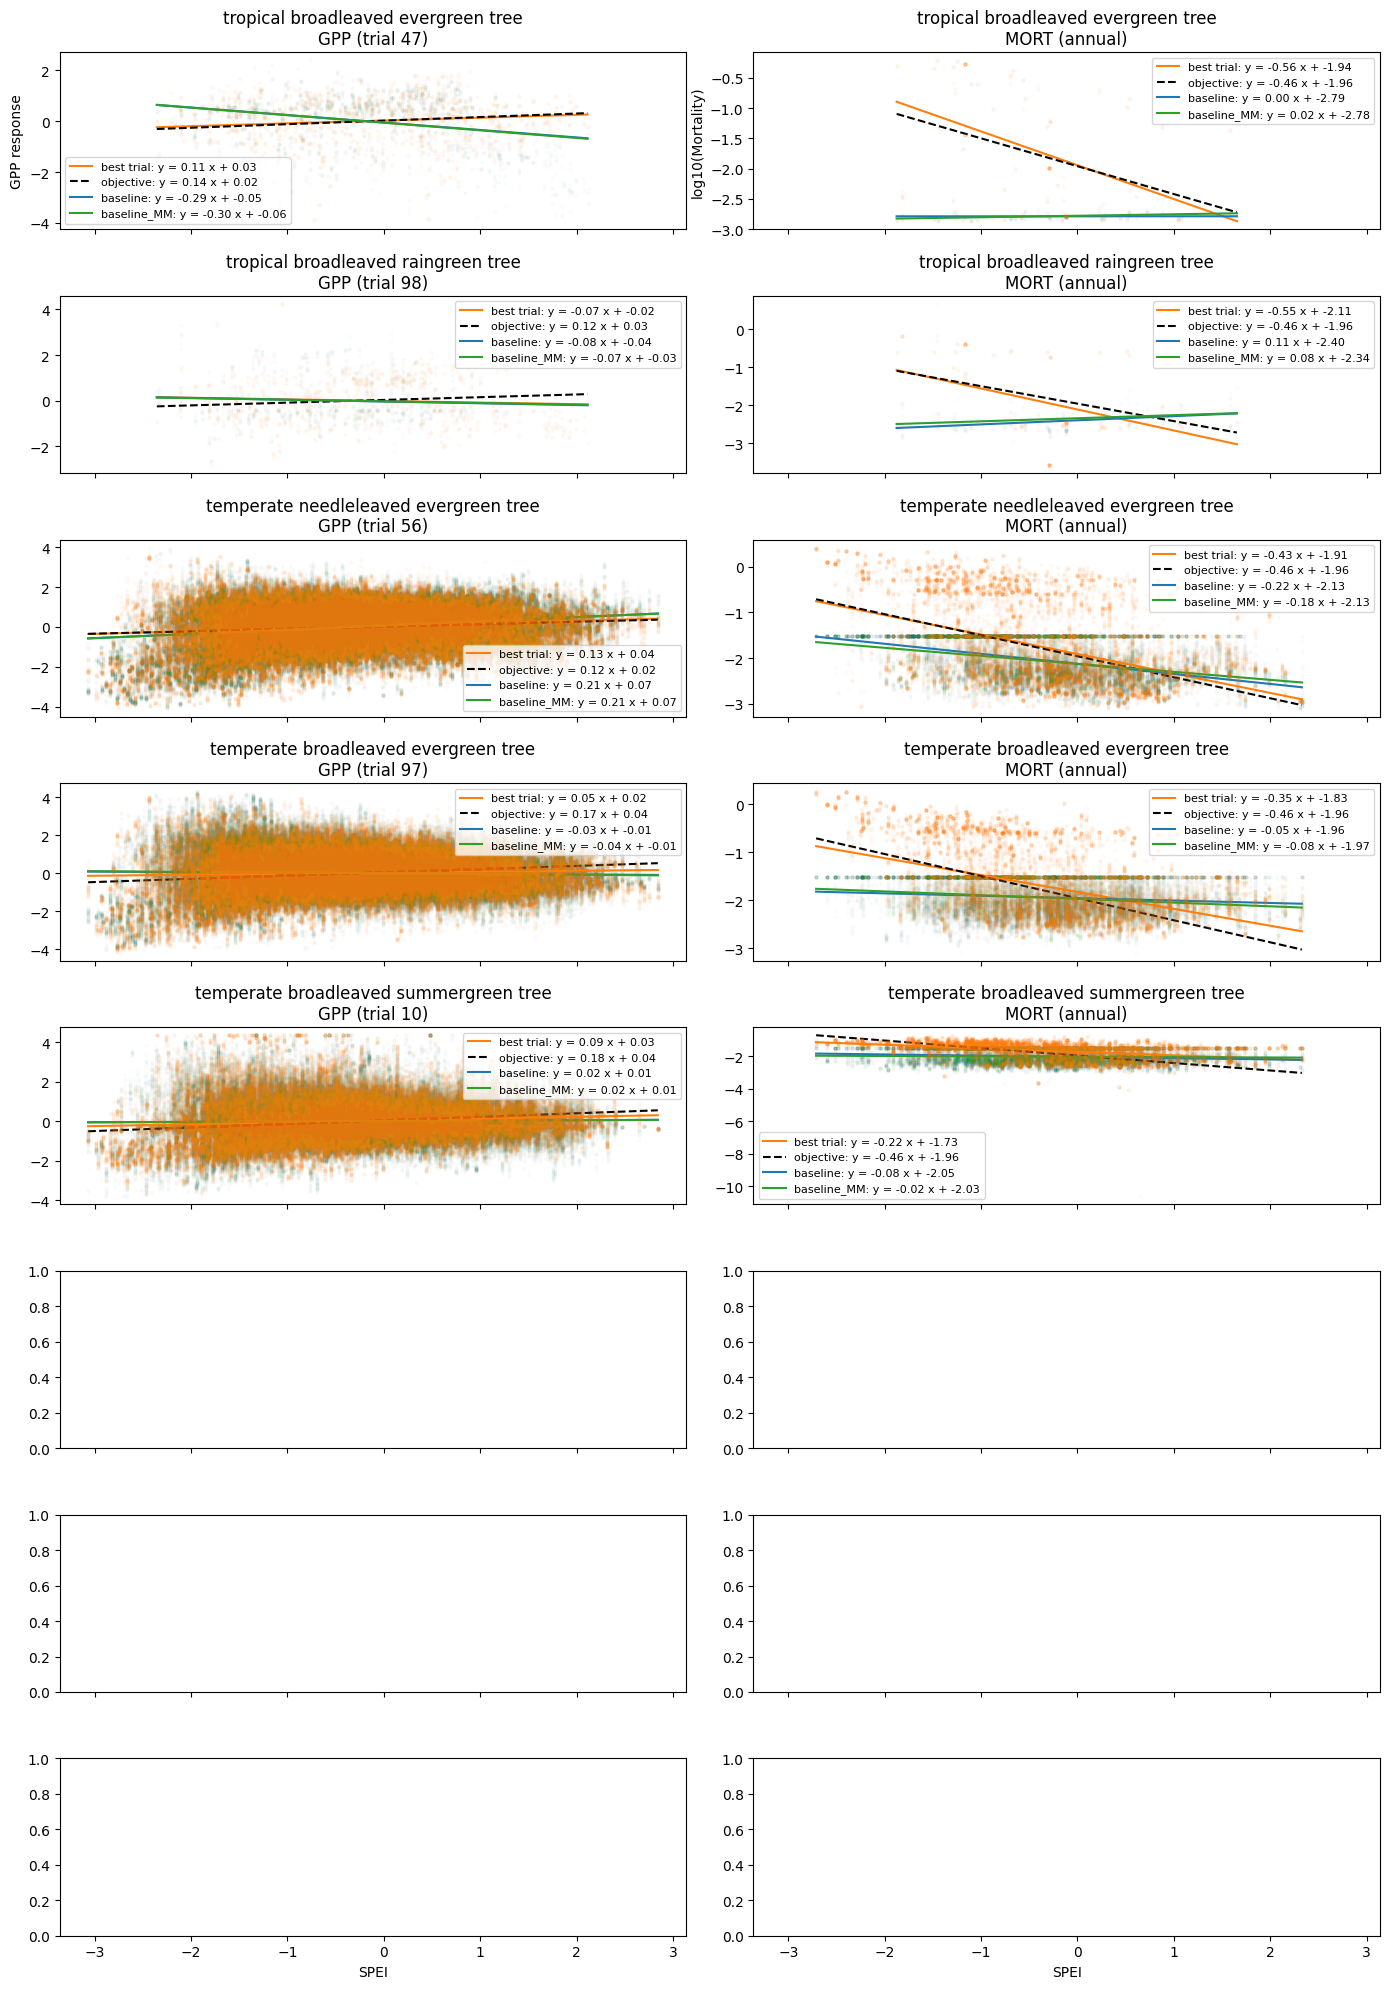

In [10]:
plot_gpp_mort_separated(
    knee_cache=knee_cache,
    OUTPUT_DIR=OUTPUT_DIR,
    BASELINE_DIR = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline",
    BASELINE_DIR_MM = "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline_MM",
    locations=locations,
    obs_spei=obs_spei,
    START_YEAR=2000,
    END_YEAR=2019,
    S_obs_gpp_water=S_obs_gpp_water,
    intercept_gpp=intercept_gpp,
    S_obs_mort=-0.46,
    intercept_mort=-1.96,
    standardized_anomalies=standardized_anomalies
)

In [24]:
mort_trial20 = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/trial_0097/patch_6/output/pft_mort.nc").mortality
mort_base_MM = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline_MM/patch_6/output/pft_mort.nc").mortality.sel(time = slice("1960", "2019"))
mort_base = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline/patch_6/output/pft_mort.nc").mortality.sel(time = slice("1960", "2019")).resample(time = "YS").sum()
mort_trial20

<xarray.DataArray 'mortality' (time: 720, pft: 11, lat: 9, lon: 7)> Size: 2MB
[498960 values with dtype=float32]
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 72B -26.25 -26.15 -26.05 ... -25.65 -25.55 -25.45
  * lon      (lon) float64 56B -62.75 -62.65 -62.55 -62.45 -62.35 -62.25 -62.15
Attributes:
    units:          1/month
    standard_name:  mortality
    long_name:      Monthly mortality

In [25]:
FPC_trial20 = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/trial_0097/patch_6/output/fpc.nc").FPC[:,1:]
FPC_base_MM = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline_MM/patch_6/output/fpc.nc").FPC[:,1:].sel(time = slice("1960", "2019"))
FPC_base = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/temperate_broadleaved_evergreen_tree/baseline/patch_6/output/fpc.nc").FPC[:,1:].sel(time = slice("1960", "2019"))

FPC_base["pft"] = FPC_base.pft - 1
FPC_base_MM["pft"] = FPC_base_MM.pft - 1
FPC_trial20['pft'] = FPC_trial20.pft - 1
FPC_trial20

<xarray.DataArray 'FPC' (time: 720, pft: 11, lat: 9, lon: 7)> Size: 2MB
[498960 values with dtype=float32]
Coordinates:
  * time     (time) object 6kB 1960-01-16 00:00:00 ... 2019-12-16 00:00:00
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 72B -26.25 -26.15 -26.05 ... -25.65 -25.55 -25.45
  * lon      (lon) float64 56B -62.75 -62.65 -62.55 -62.45 -62.35 -62.25 -62.15
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

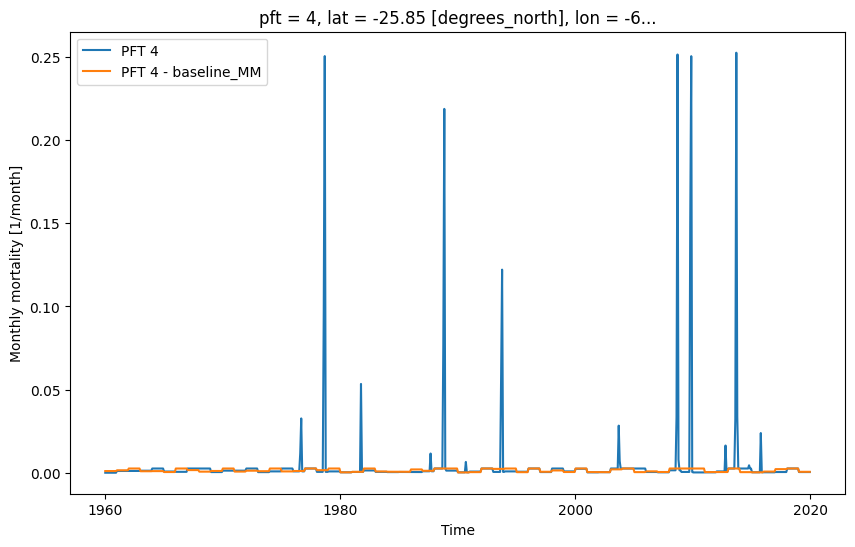

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

mort_trial20[:,3,4,4].plot(label = f"PFT 4")
mort_base_MM[:,3,4,4].plot(label = f"PFT 4 - baseline_MM")
# mort_base[:,6,4,4].plot(label = f"PFT 7 - baseline")
plt.legend()

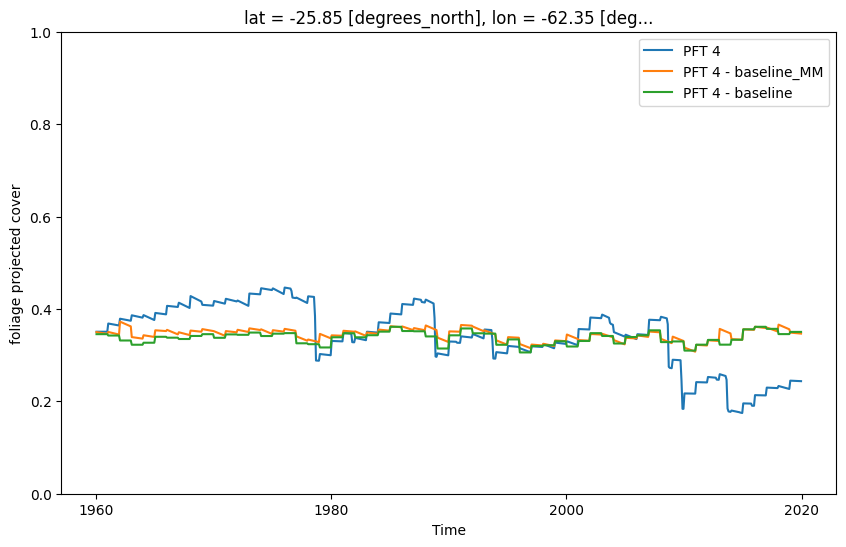

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

FPC_trial20[:,3,4,4].plot(label = f"PFT {4}")
FPC_base_MM[:,3,4,4].plot(label = f"PFT {4} - baseline_MM")
FPC_base[:,3,4,4].plot(label = f"PFT {4} - baseline")
plt.ylim(0,1)
plt.legend()

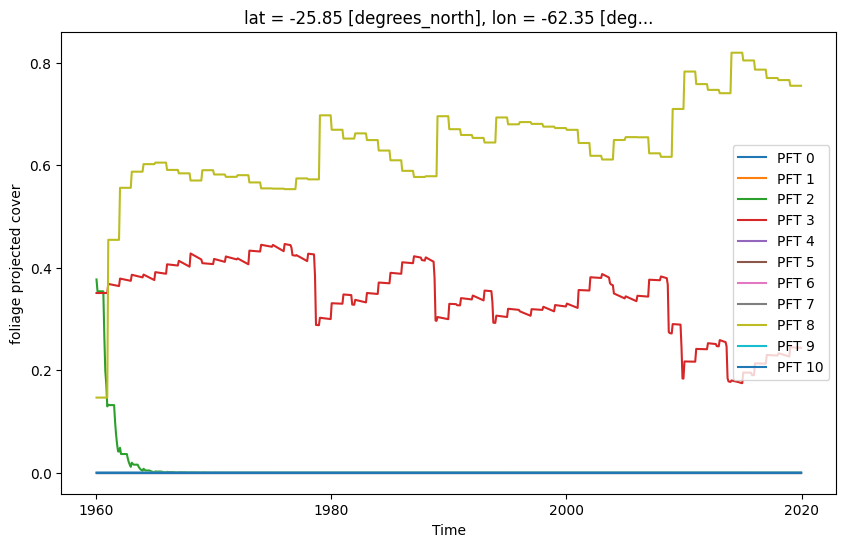

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for i in range(11):
    FPC_trial20[:,i,4,4].plot(label = f"PFT {i}")
    plt.legend()

In [16]:
pft_list = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

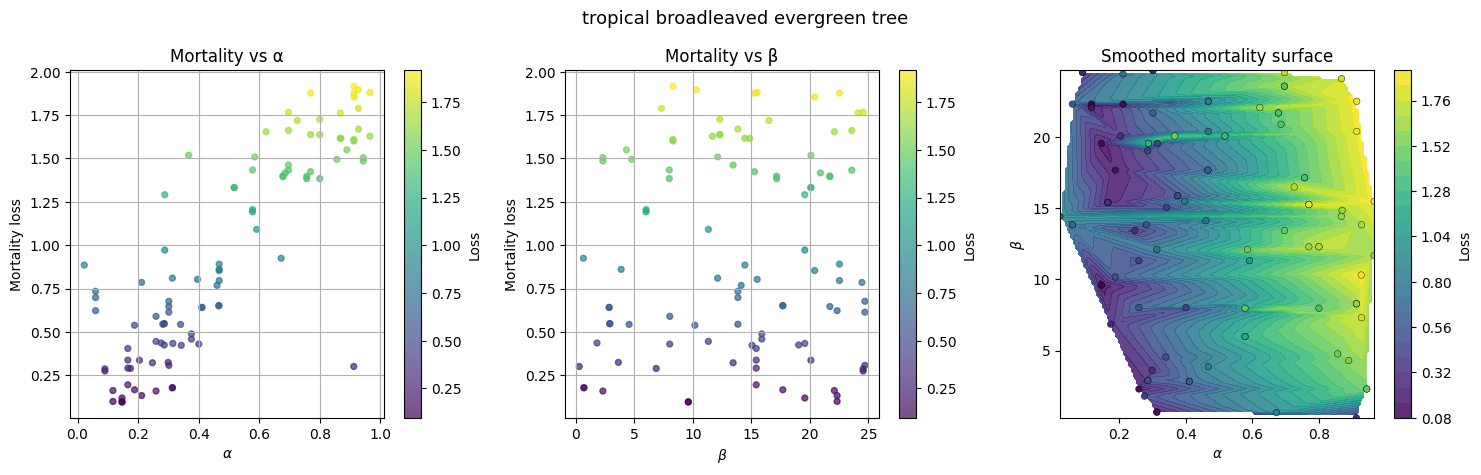

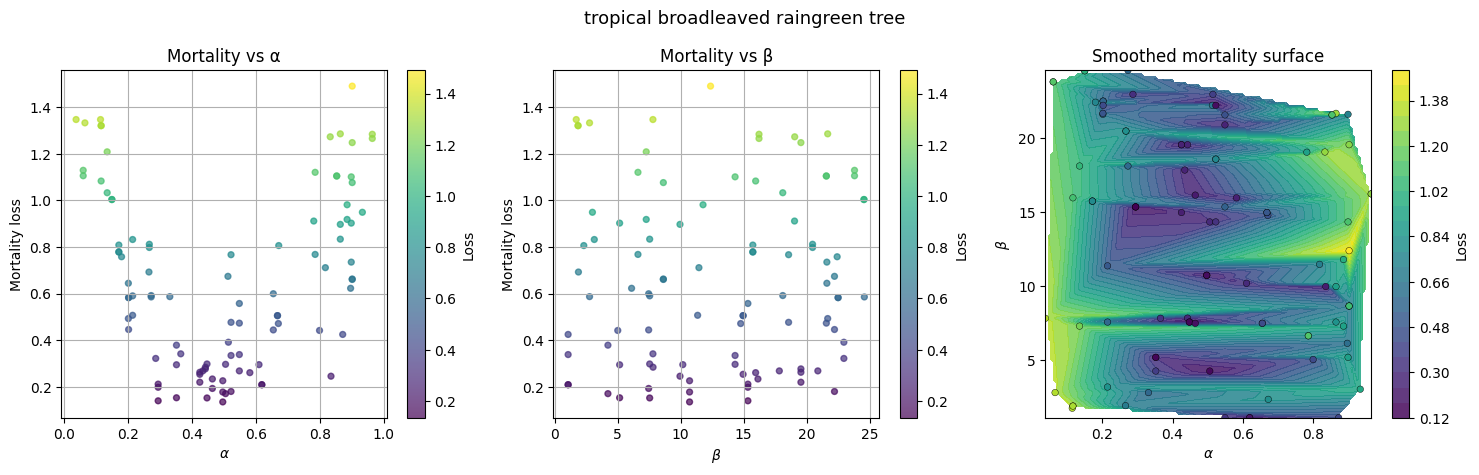

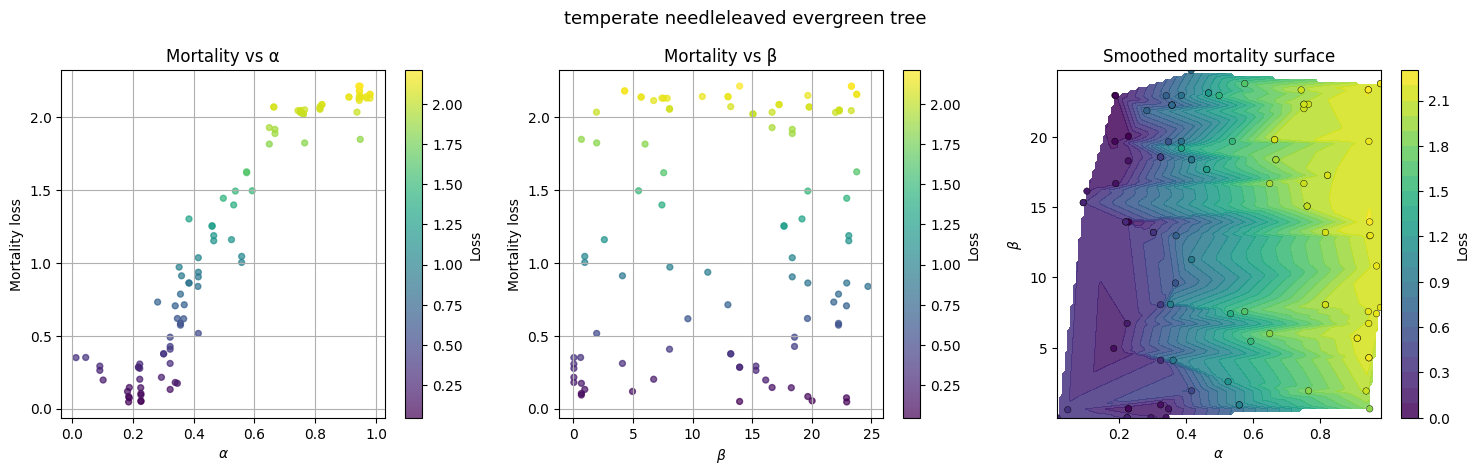

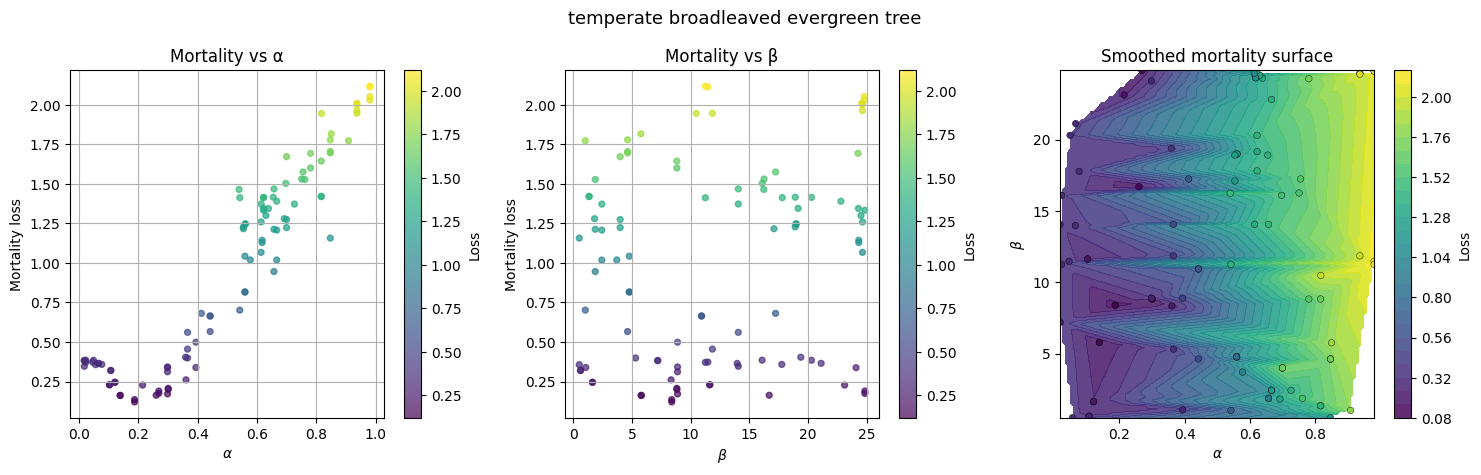

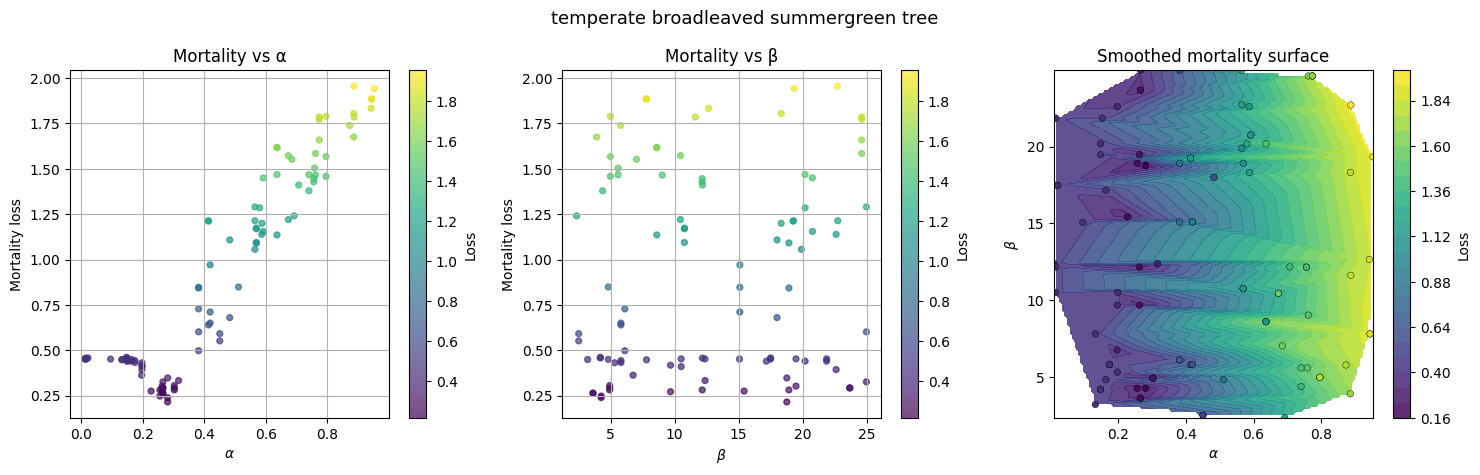

In [29]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

pft_list = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

for pft in pft_list:

    pft_key = pft.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    if alpha_col not in df.columns or beta_col not in df.columns:
        continue

    mort_df = df[
        (df["pft"] == pft) &
        (df["process"] == "MORT")
    ].copy()

    mort_df = mort_df.dropna(subset=[alpha_col, beta_col, "loss"])

    if mort_df.empty:
        continue

    x = mort_df[alpha_col].values
    y = mort_df[beta_col].values
    z = mort_df["loss"].values

    # ---------------------------------------
    # Interpolation grid
    # ---------------------------------------
    xi = np.linspace(x.min(), x.max(), 120)
    yi = np.linspace(y.min(), y.max(), 120)
    Xi, Yi = np.meshgrid(xi, yi)

    # ---------------------------------------
    # Interpolation grid (only if 2D)
    # ---------------------------------------
    do_surface = (np.unique(x).size >= 3) and (np.unique(y).size >= 3)

    if do_surface:
        xi = np.linspace(x.min(), x.max(), 120)
        yi = np.linspace(y.min(), y.max(), 120)
        Xi, Yi = np.meshgrid(xi, yi)

        Zi = griddata(
            (x, y), z,
            (Xi, Yi),
            method="linear"
        )
    else:
        Xi = Yi = Zi = None


    # ---------------------------------------
    # Plot
    # ---------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # ---- Mortality vs alpha
    sc0 = axes[0].scatter(
        x, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[0].set_xlabel(r"$\alpha$")
    axes[0].set_ylabel("Mortality loss")
    axes[0].set_title("Mortality vs α")
    axes[0].grid(True)
    fig.colorbar(sc0, ax=axes[0], label="Loss")

    # ---- Mortality vs beta
    sc1 = axes[1].scatter(
        y, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[1].set_xlabel(r"$\beta$")
    axes[1].set_ylabel("Mortality loss")
    axes[1].set_title("Mortality vs β")
    axes[1].grid(True)
    fig.colorbar(sc1, ax=axes[1], label="Loss")
    
    # ---- Alpha–beta surface + samples
    if Zi is not None and np.isfinite(Zi).any():
        cf = axes[2].contourf(
            Xi, Yi, Zi,
            levels=25,
            cmap="viridis",
            alpha=0.85
        )
    fig.colorbar(cf, ax=axes[2], label="Loss")

    sc2 = axes[2].scatter(
        x, y,
        c=z,
        s=22,
        edgecolor="k",
        linewidth=0.3
    )

    axes[2].set_xlabel(r"$\alpha$")
    axes[2].set_ylabel(r"$\beta$")
    axes[2].set_title(
        "Smoothed mortality surface" if Zi is not None else "Sampled parameter space"
    )
    

    fig.suptitle(pft, fontsize=13)
    plt.tight_layout()
    plt.show()


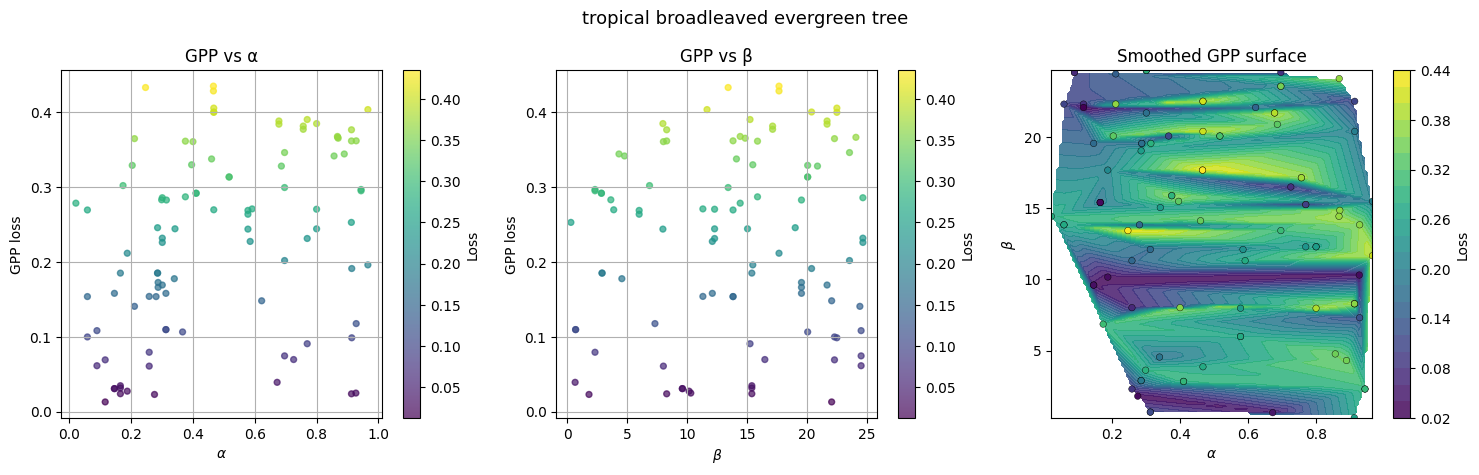

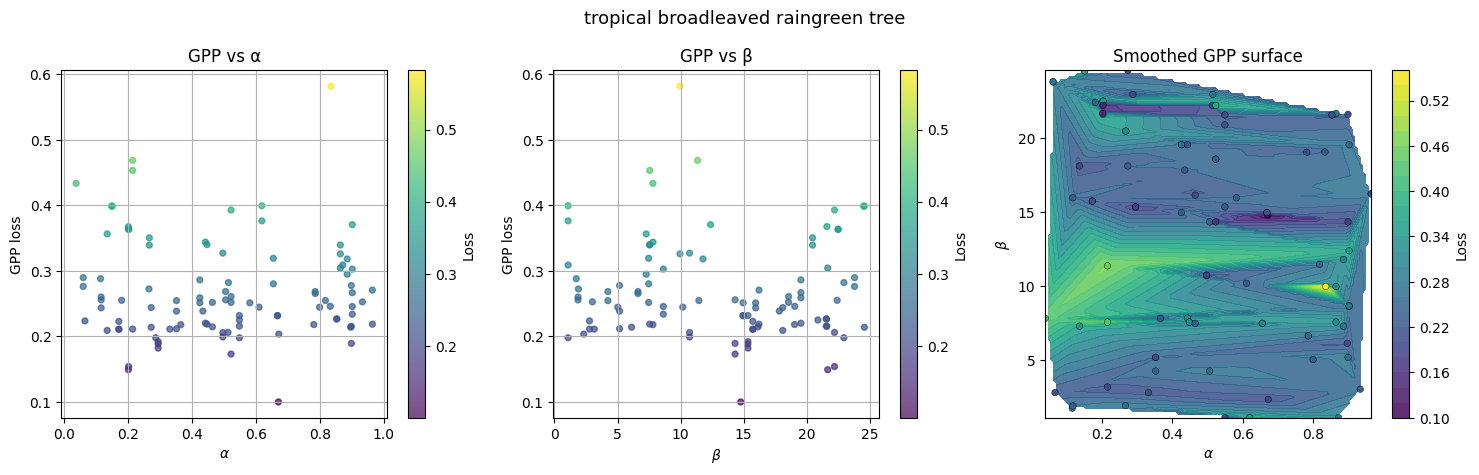

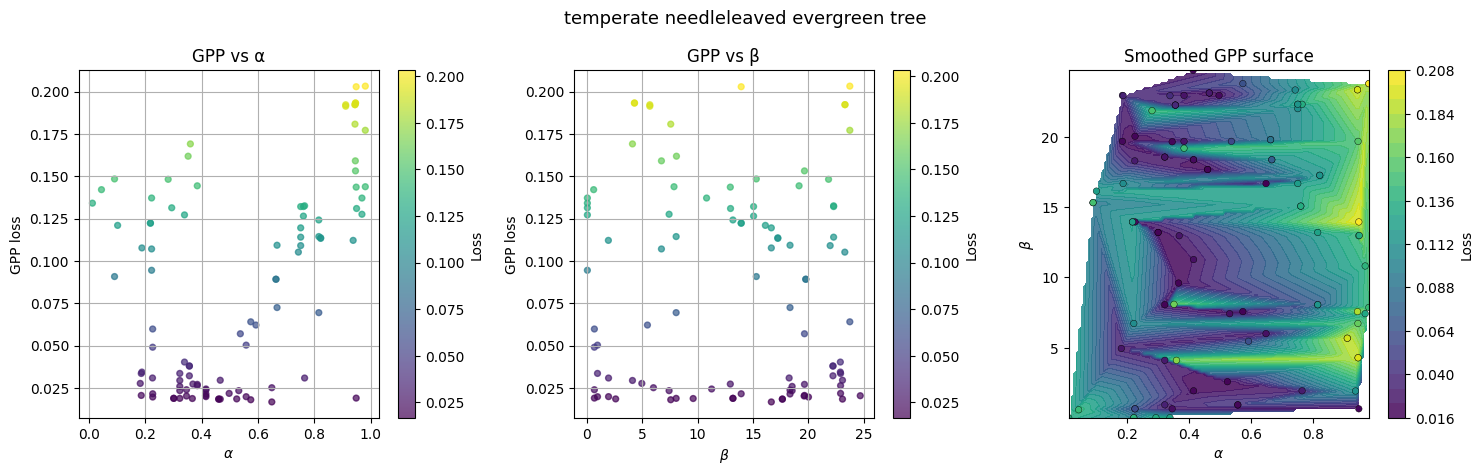

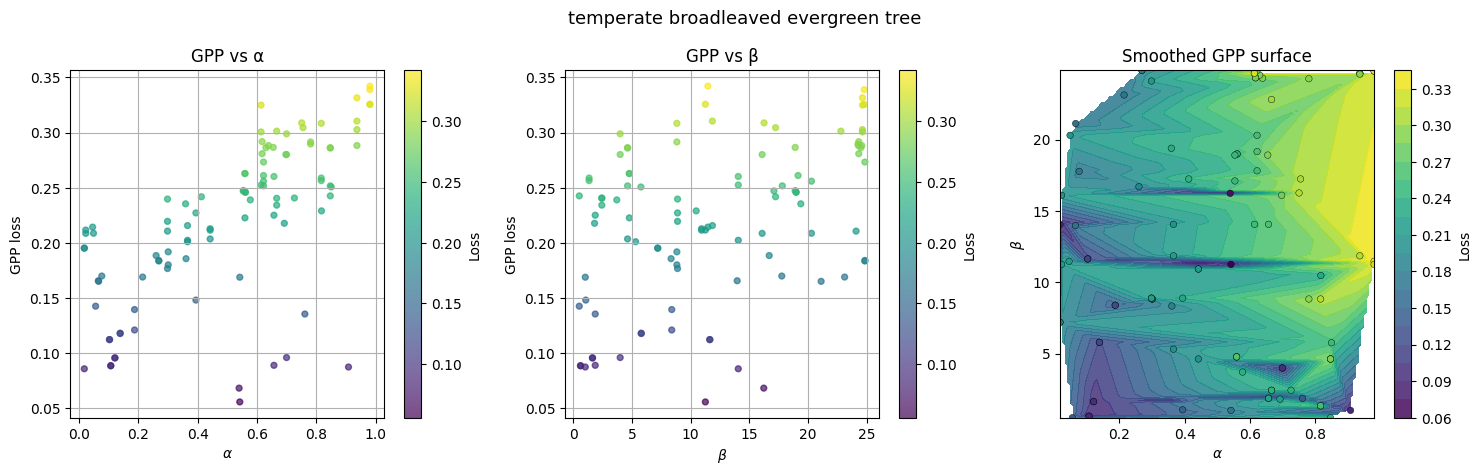

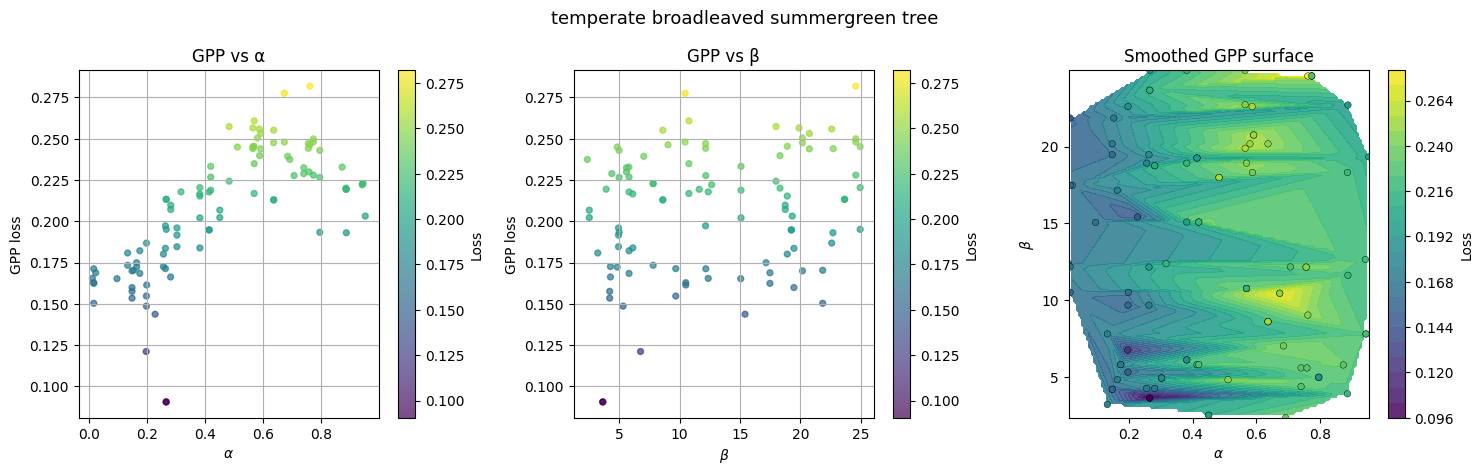

In [30]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

pft_list = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree",
]

for pft in pft_list:

    pft_key = pft.replace(" ", "_")
    alpha_col = f"alpha_{pft_key}"
    beta_col  = f"beta_{pft_key}"

    if alpha_col not in df.columns or beta_col not in df.columns:
        continue

    mort_df = df[
        (df["pft"] == pft) &
        (df["process"] == "GPP_water")
    ].copy()

    mort_df = mort_df.dropna(subset=[alpha_col, beta_col, "loss"])

    if mort_df.empty:
        continue

    x = mort_df[alpha_col].values
    y = mort_df[beta_col].values
    z = mort_df["loss"].values

    # ---------------------------------------
    # Interpolation grid
    # ---------------------------------------
    xi = np.linspace(x.min(), x.max(), 120)
    yi = np.linspace(y.min(), y.max(), 120)
    Xi, Yi = np.meshgrid(xi, yi)

    # ---------------------------------------
    # Interpolation grid (only if 2D)
    # ---------------------------------------
    do_surface = (np.unique(x).size >= 3) and (np.unique(y).size >= 3)

    if do_surface:
        xi = np.linspace(x.min(), x.max(), 120)
        yi = np.linspace(y.min(), y.max(), 120)
        Xi, Yi = np.meshgrid(xi, yi)

        Zi = griddata(
            (x, y), z,
            (Xi, Yi),
            method="linear"
        )
    else:
        Xi = Yi = Zi = None


    # ---------------------------------------
    # Plot
    # ---------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # ---- Mortality vs alpha
    sc0 = axes[0].scatter(
        x, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[0].set_xlabel(r"$\alpha$")
    axes[0].set_ylabel("GPP loss")
    axes[0].set_title("GPP vs α")
    axes[0].grid(True)
    fig.colorbar(sc0, ax=axes[0], label="Loss")

    # ---- Mortality vs beta
    sc1 = axes[1].scatter(
        y, z,
        c=z,
        s=18,
        alpha=0.7
    )
    axes[1].set_xlabel(r"$\beta$")
    axes[1].set_ylabel("GPP loss")
    axes[1].set_title("GPP vs β")
    axes[1].grid(True)
    fig.colorbar(sc1, ax=axes[1], label="Loss")
    
    # ---- Alpha–beta surface + samples
    if Zi is not None and np.isfinite(Zi).any():
        cf = axes[2].contourf(
            Xi, Yi, Zi,
            levels=25,
            cmap="viridis",
            alpha=0.85
        )
    fig.colorbar(cf, ax=axes[2], label="Loss")

    sc2 = axes[2].scatter(
        x, y,
        c=z,
        s=22,
        edgecolor="k",
        linewidth=0.3
    )

    axes[2].set_xlabel(r"$\alpha$")
    axes[2].set_ylabel(r"$\beta$")
    axes[2].set_title(
        "Smoothed GPP surface" if Zi is not None else "Sampled parameter space"
    )
    

    fig.suptitle(pft, fontsize=13)
    plt.tight_layout()
    plt.show()
